Import Dataset

In [0]:
df_spark = spark.table("gold.dataset_ml")
df = df_spark.toPandas()
df = df[df["approved"].notna()].copy()
df["approved"] = df["approved"].astype(int)
# Remove embeddings
emb_features = [c for c in df.columns if c.startswith("emb_")]
df = df.drop(columns=emb_features)

print("Rows:", len(df))
print("\nTarget distribution:")
print(df["approved"].value_counts())
print("\nTarget proportion:")
print(df["approved"].value_counts(normalize=True))
display(df.limit(5))

Rows: 3770

Target distribution:
approved
1    2569
0    1201
Name: count, dtype: int64

Target proportion:
approved
1    0.681432
0    0.318568
Name: proportion, dtype: float64


---------------------------------------------------------------------------
AttributeError                            Traceback (most recent call last)
~/.ipykernel/10416/command-8713255381029897-1017672853 in ?()
     10 print("\nTarget distribution:")
     11 print(df["approved"].value_counts())
     12 print("\nTarget proportion:")
     13 print(df["approved"].value_counts(normalize=True))
---> 14 display(df.limit(5))

/databricks/python/lib/python3.12/site-packages/pandas/core/generic.py in ?(self, name)
   6295             and name not in self._accessors
   6296             and self._info_axis._can_hold_identifiers_and_holds_name(name)
   6297         ):
   6298             return self[name]
-> 6299         return object.__getattribute__(self, name)

AttributeError: 'DataFrame' object has no attribute 'limit'

Define fields groups

In [0]:
# Community Louvain Feature
df["community_louvain"] = df["community_louvain"].astype(int)
community_counts = df["community_louvain"].value_counts()
df["community_size"] = df["community_louvain"].map(community_counts).fillna(0)

# Graph Features
graph_features = [
    "degree_total",
    "degree_norm",
    "pagerank_norm",
    "betweenness_norm",
    "closeness_norm",
    "community_size"
]



# Variables BASE
numeric_features_zero = ["n_facilities", "n_countries"]

numeric_features_other = [
    "n_interventions",
    "n_sponsor_lead",
    "n_sponsor_collaborator",
    "n_sponsors_total",
    "n_conditions"
]

categorical_features = [
    "allocation",
    "primary_purpose",
    "masking",
    "intervention_model",
    "is_blinded"
]

text_feature = "brief_title"

df[categorical_features] = df[categorical_features].fillna("UNKNOWN").astype(str)
df[text_feature] = df[text_feature].fillna("").astype(str)

numeric_features_full = (
    numeric_features_zero +
    numeric_features_other +
    graph_features 
)




Define X and y

In [0]:
id_cols = ["study_id"]

y = df["approved"].astype(int)
#Base
X_base = df.drop(
    columns=graph_features  + [text_feature, "approved", "community_louvain"] + id_cols,
    errors="ignore"
)
# Tabular + Text 
X_text = df.drop(
    columns=graph_features  + ["approved", "community_louvain"] + id_cols,
    errors="ignore"
)

# Tabular + Graph
X_graph = df.drop(
    columns=  [text_feature, "approved", "community_louvain"] + id_cols,
    errors="ignore"
)



# Tabular + Text + Graph 
X_graph_text = df.drop(
    columns=["approved", "community_louvain"] + id_cols,
    errors="ignore"
)
print("BASE:", list(X_base.columns))
print("TEXT:", list(X_text.columns))
print("GRAPH:", list(X_graph.columns))

print("FULL:", list(X_graph_text.columns))

BASE: ['n_conditions', 'n_countries', 'n_interventions', 'n_facilities', 'n_sponsor_lead', 'n_sponsor_collaborator', 'n_sponsors_total', 'allocation', 'primary_purpose', 'intervention_model', 'masking', 'is_blinded']
TEXT: ['brief_title', 'n_conditions', 'n_countries', 'n_interventions', 'n_facilities', 'n_sponsor_lead', 'n_sponsor_collaborator', 'n_sponsors_total', 'allocation', 'primary_purpose', 'intervention_model', 'masking', 'is_blinded']
GRAPH: ['degree_total', 'degree_norm', 'pagerank_norm', 'betweenness_norm', 'closeness_norm', 'n_conditions', 'n_countries', 'n_interventions', 'n_facilities', 'n_sponsor_lead', 'n_sponsor_collaborator', 'n_sponsors_total', 'allocation', 'primary_purpose', 'intervention_model', 'masking', 'is_blinded', 'community_size']
FULL: ['brief_title', 'degree_total', 'degree_norm', 'pagerank_norm', 'betweenness_norm', 'closeness_norm', 'n_conditions', 'n_countries', 'n_interventions', 'n_facilities', 'n_sponsor_lead', 'n_sponsor_collaborator', 'n_sponsors

Train/Test

In [0]:
from sklearn.model_selection import train_test_split

# Split data
idx_train, idx_test = train_test_split(
    df.index,
    test_size=0.30,
    random_state=42,
    stratify=y
)


# BASE
X_base_train = X_base.loc[idx_train]
X_base_test  = X_base.loc[idx_test]

# TABULAR + TEXT
X_text_train = X_text.loc[idx_train]
X_text_test  = X_text.loc[idx_test]

# TABULAR + GRAPH

X_graph_train = X_graph.loc[idx_train]
X_graph_test  = X_graph.loc[idx_test]



# FULL
# Tabular + texto + métricas 
X_graph_text_train = X_graph_text.loc[idx_train]
X_graph_text_test  = X_graph_text.loc[idx_test]

# TARGET
y_train = y.loc[idx_train]
y_test  = y.loc[idx_test]

# Trazability
study_train = df.loc[idx_train, "study_id"]
study_test  = df.loc[idx_test, "study_id"]

print("Train size:", len(y_train))
print("Test size:", len(y_test))

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Train size: 2639
Test size: 1131

Train target distribution:
approved
1    0.681319
0    0.318681
Name: proportion, dtype: float64

Test target distribution:
approved
1    0.681698
0    0.318302
Name: proportion, dtype: float64


Preprocess

In [0]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

text_transformer = Pipeline(steps=[
    ("to_1d", FunctionTransformer(
        lambda x: (
            x.iloc[:, 0]
            if isinstance(x, pd.DataFrame)
            else (x.ravel() if isinstance(x, np.ndarray) else x)
        ).fillna("").astype(str),
        validate=False
    )),
    ("tfidf", TfidfVectorizer(
        max_features=5000,        
        ngram_range=(1, 2),
        min_df=5,                
        max_df=0.8,              
        stop_words="english"
    ))
])

In [0]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# TREE: RF / XGB

preprocess_tree_base = ColumnTransformer(
    transformers=[
        ("num_zero", SimpleImputer(strategy="constant", fill_value=0), numeric_features_zero),
        ("num_other", SimpleImputer(strategy="median"), numeric_features_other),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ],
    remainder="drop",
    sparse_threshold=1.0
)

preprocess_tree_text = ColumnTransformer(
    transformers=[
        ("num_zero", SimpleImputer(strategy="constant", fill_value=0), numeric_features_zero),
        ("num_other", SimpleImputer(strategy="median"), numeric_features_other),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features),
        ("text", text_transformer, [text_feature])
    ],
    remainder="drop",
    sparse_threshold=1.0
)

preprocess_tree_graph = ColumnTransformer(
    transformers=[
        ("num_zero", SimpleImputer(strategy="constant", fill_value=0), numeric_features_zero),
        ("num_other", SimpleImputer(strategy="median"),
         numeric_features_other + graph_features ),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ],
    remainder="drop",
    sparse_threshold=1.0
)

preprocess_tree_graph_text = ColumnTransformer(
    transformers=[
        ("num_zero", SimpleImputer(strategy="constant", fill_value=0), numeric_features_zero),
        ("num_other", SimpleImputer(strategy="median"),
         numeric_features_other + graph_features ),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features),
        ("text", text_transformer, [text_feature])
    ],
    remainder="drop",
    sparse_threshold=1.0
)

# LINEAR: Logistic Regression / SVM

preprocess_linear_base = ColumnTransformer(
    transformers=[
        ("num_zero", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
            ("scaler", StandardScaler(with_mean=False))
        ]), numeric_features_zero),
        ("num_other", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler(with_mean=False))
        ]), numeric_features_other),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ],
    remainder="drop",
    sparse_threshold=1.0
)

preprocess_linear_text = ColumnTransformer(
    transformers=[
        ("num_zero", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
            ("scaler", StandardScaler(with_mean=False))
        ]), numeric_features_zero),
        ("num_other", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler(with_mean=False))
        ]), numeric_features_other),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features),
        ("text", text_transformer, [text_feature])
    ],
    remainder="drop",
    sparse_threshold=1.0
)

preprocess_linear_graph = ColumnTransformer(
    transformers=[
        ("num_zero", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
            ("scaler", StandardScaler(with_mean=False))
        ]), numeric_features_zero),
        ("num_other", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler(with_mean=False))
        ]), numeric_features_other + graph_features ),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ],
    remainder="drop",
    sparse_threshold=1.0
)

preprocess_linear_graph_text = ColumnTransformer(
    transformers=[
        ("num_zero", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
            ("scaler", StandardScaler(with_mean=False))
        ]), numeric_features_zero),
        ("num_other", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler(with_mean=False))
        ]), numeric_features_other + graph_features ),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features),
        ("text", text_transformer, [text_feature])
    ],
    remainder="drop",
    sparse_threshold=1.0
)


###Logistic Regresion

Logistic Regression Base

In [0]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import pandas as pd

# CV
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# PIPELINE BASE 
logreg_base_pipe = Pipeline(steps=[
    ("preprocess", preprocess_linear_base),  
    ("clf", LogisticRegression(
        max_iter=10000,
        solver="liblinear",
        class_weight="balanced",
        random_state=42
    ))
])

# GRID
param_grid_logreg = [
    {
        "clf__penalty": ["l1", "l2"],
        "clf__C": [0.001, 0.01, 0.1, 1.0, 10.0]
    }
]

grid_logreg_base = GridSearchCV(
    estimator=logreg_base_pipe,
    param_grid=param_grid_logreg,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# TRAIN 
grid_logreg_base.fit(X_base_train, y_train)

best_logreg_base = grid_logreg_base.best_estimator_

print("Best Logistic Regression BASE params:", grid_logreg_base.best_params_)
print("Best CV f1_macro:", grid_logreg_base.best_score_)

# TEST 
proba_base = best_logreg_base.predict_proba(X_base_test)[:, 1]
pred_base = (proba_base >= 0.5).astype(int)

print("\nLogistic Regression BASE | Test independiente | threshold=0.5")
print(classification_report(y_test, pred_base))
print("Confusion:\n", confusion_matrix(y_test, pred_base))
print("AUC:", roc_auc_score(y_test, proba_base))

# RESULTS
logreg_base_test_results = {
    "model": "Logistic Regression",
    "strategy": "BASE (TABULAR ONLY)",
    "best_cv_f1_macro": grid_logreg_base.best_score_,
    "accuracy": accuracy_score(y_test, pred_base),
    "precision_macro": precision_score(y_test, pred_base, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, pred_base, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, pred_base, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_test, proba_base),
    "best_params": grid_logreg_base.best_params_
}

pd.DataFrame([logreg_base_test_results])

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Logistic Regression BASE params: {'clf__C': 1.0, 'clf__penalty': 'l2'}
Best CV f1_macro: 0.6493304438455791

Logistic Regression BASE | Test independiente | threshold=0.5
              precision    recall  f1-score   support

           0       0.47      0.53      0.50       360
           1       0.77      0.72      0.75       771

    accuracy                           0.66      1131
   macro avg       0.62      0.63      0.62      1131
weighted avg       0.67      0.66      0.67      1131

Confusion:
 [[192 168]
 [213 558]]
AUC: 0.6812040639861651


,model,strategy,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,best_params
0,Logistic Regression,BASE (TABULAR ONLY),0.64933,0.66313,0.621335,0.628534,0.623726,0.681204,"{'clf__C': 1.0, 'clf__penalty': 'l2'}"


Tabular + Text

In [0]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import pandas as pd

# CV
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# PIPELINE (TABULAR + TEXT)
logreg_text_pipe = Pipeline(steps=[
    ("preprocess", preprocess_linear_text),
    ("clf", LogisticRegression(
        max_iter=10000,
        solver="liblinear",
        class_weight="balanced",
        random_state=42
    ))
])

# GRID
param_grid_logreg = {
    "clf__penalty": ["l1", "l2"],
    "clf__C": [0.001, 0.01, 0.1, 1.0, 10.0]
}

grid_logreg_text = GridSearchCV(
    estimator=logreg_text_pipe,
    param_grid=param_grid_logreg,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# TRAIN 
grid_logreg_text.fit(X_text_train, y_train)

best_logreg_text = grid_logreg_text.best_estimator_

print("Best Logistic Regression TABULAR + TEXT params:", grid_logreg_text.best_params_)
print("Best CV f1_macro:", grid_logreg_text.best_score_)

# TEST 
proba_text = best_logreg_text.predict_proba(X_text_test)[:, 1]
pred_text = (proba_text >= 0.5).astype(int)

print("\nLogistic Regression TABULAR + TEXT | Test independiente | threshold=0.5")
print(classification_report(y_test, pred_text))
print("Confusion:\n", confusion_matrix(y_test, pred_text))
print("AUC:", roc_auc_score(y_test, proba_text))

# RESULTS
logreg_text_test_results = {
    "model": "Logistic Regression",
    "strategy": "TABULAR + TEXT",
    "best_cv_f1_macro": grid_logreg_text.best_score_,
    "accuracy": accuracy_score(y_test, pred_text),
    "precision_macro": precision_score(y_test, pred_text, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, pred_text, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, pred_text, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_test, proba_text),
    "best_params": grid_logreg_text.best_params_
}

pd.DataFrame([logreg_text_test_results])

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Logistic Regression TABULAR + TEXT params: {'clf__C': 1.0, 'clf__penalty': 'l2'}
Best CV f1_macro: 0.6972577756819214

Logistic Regression TABULAR + TEXT | Test independiente | threshold=0.5
              precision    recall  f1-score   support

           0       0.58      0.66      0.62       360
           1       0.83      0.77      0.80       771

    accuracy                           0.74      1131
   macro avg       0.70      0.72      0.71      1131
weighted avg       0.75      0.74      0.74      1131

Confusion:
 [[239 121]
 [176 595]]
AUC: 0.7765095835134745


,model,strategy,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,best_params
0,Logistic Regression,TABULAR + TEXT,0.697258,0.737401,0.703455,0.717807,0.708522,0.77651,"{'clf__C': 1.0, 'clf__penalty': 'l2'}"


Graph

In [0]:
# Logistic Regression - TABULAR + GRAPH

logreg_graph_pipe = Pipeline(steps=[
    ("preprocess", preprocess_linear_graph),
    ("clf", LogisticRegression(
        max_iter=10000,
        solver="liblinear",
        class_weight="balanced",
        random_state=42
    ))
])

param_grid_logreg = {
    "clf__penalty": ["l1", "l2"],
    "clf__C": [0.001, 0.01, 0.1, 1.0, 10.0]
}

grid_logreg_graph = GridSearchCV(
    estimator=logreg_graph_pipe,
    param_grid=param_grid_logreg,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# TRAIN
grid_logreg_graph.fit(X_graph_train, y_train)

best_logreg_graph = grid_logreg_graph.best_estimator_

print("Best Logistic Regression TABULAR + GRAPH params:", grid_logreg_graph.best_params_)
print("Best CV f1_macro:", grid_logreg_graph.best_score_)

# TEST
proba_graph = best_logreg_graph.predict_proba(X_graph_test)[:, 1]
pred_graph = (proba_graph >= 0.5).astype(int)

print("\nLogistic Regression TABULAR + GRAPH | Test independiente | threshold=0.5")
print(classification_report(y_test, pred_graph))
print("Confusion:\n", confusion_matrix(y_test, pred_graph))
print("AUC:", roc_auc_score(y_test, proba_graph))

# RESULTS
logreg_graph_test_results = {
    "model": "Logistic Regression",
    "strategy": "TABULAR + GRAPH",
    "best_cv_f1_macro": grid_logreg_graph.best_score_,
    "accuracy": accuracy_score(y_test, pred_graph),
    "precision_macro": precision_score(y_test, pred_graph, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, pred_graph, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, pred_graph, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_test, proba_graph),
    "best_params": grid_logreg_graph.best_params_
}

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Logistic Regression TABULAR + GRAPH params: {'clf__C': 1.0, 'clf__penalty': 'l1'}
Best CV f1_macro: 0.6598346564156746

Logistic Regression TABULAR + GRAPH | Test independiente | threshold=0.5
              precision    recall  f1-score   support

           0       0.50      0.57      0.53       360
           1       0.78      0.73      0.76       771

    accuracy                           0.68      1131
   macro avg       0.64      0.65      0.64      1131
weighted avg       0.69      0.68      0.69      1131

Confusion:
 [[205 155]
 [207 564]]
AUC: 0.7014123072488831


Logistic Regression FULL

In [0]:
# Logistic Regression - TABULAR + TEXT + GRAPH


logreg_graph_text_pipe = Pipeline(steps=[
    ("preprocess", preprocess_linear_graph_text),
    ("clf", LogisticRegression(
        max_iter=10000,
        solver="liblinear",
        class_weight="balanced",
        random_state=42
    ))
])

param_grid_logreg = {
    "clf__penalty": ["l1", "l2"],
    "clf__C": [0.001, 0.01, 0.1, 1.0, 10.0]
}

grid_logreg_graph_text = GridSearchCV(
    estimator=logreg_graph_text_pipe,
    param_grid=param_grid_logreg,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# CV 
grid_logreg_graph_text.fit(X_graph_text_train, y_train)

best_logreg_graph_text = grid_logreg_graph_text.best_estimator_

print("Best Logistic Regression TABULAR + TEXT + GRAPH params:", grid_logreg_graph_text.best_params_)
print("Best CV f1_macro:", grid_logreg_graph_text.best_score_)

# Test 
proba_graph_text = best_logreg_graph_text.predict_proba(X_graph_text_test)[:, 1]
pred_graph_text = (proba_graph_text >= 0.5).astype(int)

print("\nLogistic Regression TABULAR + TEXT + GRAPH | Test independiente | threshold=0.5")
print(classification_report(y_test, pred_graph_text))
print("Confusion:\n", confusion_matrix(y_test, pred_graph_text))
print("AUC:", roc_auc_score(y_test, proba_graph_text))

logreg_graph_text_test_results = {
    "model": "Logistic Regression",
    "strategy": "TABULAR + TEXT + GRAPH",
    "best_cv_f1_macro": grid_logreg_graph_text.best_score_,
    "accuracy": accuracy_score(y_test, pred_graph_text),
    "precision_macro": precision_score(y_test, pred_graph_text, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, pred_graph_text, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, pred_graph_text, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_test, proba_graph_text),
    "best_params": grid_logreg_graph_text.best_params_
}

pd.DataFrame([logreg_graph_text_test_results])

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Logistic Regression TABULAR + TEXT + GRAPH params: {'clf__C': 1.0, 'clf__penalty': 'l2'}
Best CV f1_macro: 0.7011302066152721

Logistic Regression TABULAR + TEXT + GRAPH | Test independiente | threshold=0.5
              precision    recall  f1-score   support

           0       0.57      0.67      0.62       360
           1       0.83      0.77      0.80       771

    accuracy                           0.74      1131
   macro avg       0.70      0.72      0.71      1131
weighted avg       0.75      0.74      0.74      1131

Confusion:
 [[242 118]
 [181 590]]
AUC: 0.7826956333765671


,model,strategy,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,best_params
0,Logistic Regression,TABULAR + TEXT + GRAPH,0.70113,0.735632,0.702719,0.718731,0.707986,0.782696,"{'clf__C': 1.0, 'clf__penalty': 'l2'}"


In [0]:
df_lr_comparison = pd.DataFrame([
    logreg_base_test_results,
    logreg_text_test_results,
    logreg_graph_test_results,
    logreg_graph_text_test_results
])

df_lr_comparison.sort_values(by="f1_macro", ascending=False)

,model,strategy,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,best_params
1,Logistic Regression,TABULAR + TEXT,0.697258,0.737401,0.703455,0.717807,0.708522,0.776510,"{'clf__C': 1.0, 'clf__penalty': 'l2'}"
3,Logistic Regression,TABULAR + TEXT + GRAPH,0.701130,0.735632,0.702719,0.718731,0.707986,0.782696,"{'clf__C': 1.0, 'clf__penalty': 'l2'}"
2,Logistic Regression,TABULAR + GRAPH,0.659835,0.679929,0.640998,0.650481,0.644068,0.701412,"{'clf__C': 1.0, 'clf__penalty': 'l1'}"
0,Logistic Regression,BASE (TABULAR ONLY),0.649330,0.663130,0.621335,0.628534,0.623726,0.681204,"{'clf__C': 1.0, 'clf__penalty': 'l2'}"


SVM Base

In [0]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
import pandas as pd

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Linear SVM - BASE (TABULAR ONLY)

svm_base_pipe = Pipeline(steps=[
    ("preprocess", preprocess_linear_base),
    ("clf", LinearSVC(
        class_weight="balanced",
        random_state=42,
        max_iter=50000
    ))
])

param_grid_svm = {
    "clf__C": [0.01, 0.1, 1.0, 5.0]
}

grid_svm_base = GridSearchCV(
    estimator=svm_base_pipe,
    param_grid=param_grid_svm,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# CV 
grid_svm_base.fit(X_base_train, y_train)

best_svm_base = grid_svm_base.best_estimator_

print("Best SVM BASE params:", grid_svm_base.best_params_)
print("Best CV f1_macro:", grid_svm_base.best_score_)

# Test 
scores_base = best_svm_base.decision_function(X_base_test)
pred_base = (scores_base >= 0).astype(int)

print("\nSVM BASE | Test independiente | threshold=0")
print(classification_report(y_test, pred_base))
print("Confusion:\n", confusion_matrix(y_test, pred_base))
print("AUC:", roc_auc_score(y_test, scores_base))

svm_base_test_results = {
    "model": "Linear SVM",
    "strategy": "BASE (TABULAR ONLY)",
    "best_cv_f1_macro": grid_svm_base.best_score_,
    "accuracy": accuracy_score(y_test, pred_base),
    "precision_macro": precision_score(y_test, pred_base, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, pred_base, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, pred_base, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_test, scores_base),
    "best_params": grid_svm_base.best_params_
}

pd.DataFrame([svm_base_test_results])

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best SVM BASE params: {'clf__C': 0.1}
Best CV f1_macro: 0.652077904478381

SVM BASE | Test independiente | threshold=0
              precision    recall  f1-score   support

           0       0.48      0.53      0.50       360
           1       0.77      0.73      0.75       771

    accuracy                           0.67      1131
   macro avg       0.62      0.63      0.63      1131
weighted avg       0.68      0.67      0.67      1131

Confusion:
 [[190 170]
 [206 565]]
AUC: 0.6812905317769131


,model,strategy,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,best_params
0,Linear SVM,BASE (TABULAR ONLY),0.652078,0.667551,0.624253,0.630296,0.626489,0.681291,{'clf__C': 0.1}


Text

In [0]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
import pandas as pd

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

svm_text_pipe = Pipeline(steps=[
    ("preprocess", preprocess_linear_text),
    ("clf", LinearSVC(
        class_weight="balanced",
        random_state=42,
        max_iter=50000
    ))
])

param_grid_svm = {
    "clf__C": [0.01, 0.1, 1.0, 5.0]
}

grid_svm_text = GridSearchCV(
    estimator=svm_text_pipe,
    param_grid=param_grid_svm,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_svm_text.fit(X_text_train, y_train)

best_svm_text = grid_svm_text.best_estimator_

print("Best SVM TABULAR + TEXT params:", grid_svm_text.best_params_)
print("Best CV f1_macro:", grid_svm_text.best_score_)

scores_text = best_svm_text.decision_function(X_text_test)
pred_text = (scores_text >= 0).astype(int)

print("\nSVM TABULAR + TEXT | Test independiente | threshold=0")
print(classification_report(y_test, pred_text))
print("Confusion:\n", confusion_matrix(y_test, pred_text))
print("AUC:", roc_auc_score(y_test, scores_text))

svm_text_test_results = {
    "model": "Linear SVM",
    "strategy": "TABULAR + TEXT",
    "best_cv_f1_macro": grid_svm_text.best_score_,
    "accuracy": accuracy_score(y_test, pred_text),
    "precision_macro": precision_score(y_test, pred_text, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, pred_text, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, pred_text, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_test, scores_text),
    "best_params": grid_svm_text.best_params_
}

pd.DataFrame([svm_text_test_results])

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best SVM TABULAR + TEXT params: {'clf__C': 0.1}
Best CV f1_macro: 0.6998869612862186

SVM TABULAR + TEXT | Test independiente | threshold=0
              precision    recall  f1-score   support

           0       0.58      0.66      0.62       360
           1       0.83      0.77      0.80       771

    accuracy                           0.74      1131
   macro avg       0.70      0.72      0.71      1131
weighted avg       0.75      0.74      0.74      1131

Confusion:
 [[238 122]
 [175 596]]
AUC: 0.7778786568669837


,model,strategy,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,best_params
0,Linear SVM,TABULAR + TEXT,0.699887,0.737401,0.703177,0.717067,0.70816,0.777879,{'clf__C': 0.1}


Graph

In [0]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
import pandas as pd

# Linear SVM - TABULAR + GRAPH

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

svm_graph_pipe = Pipeline(steps=[
    ("preprocess", preprocess_linear_graph),
    ("clf", LinearSVC(
        class_weight="balanced",
        random_state=42,
        max_iter=50000
    ))
])

param_grid_svm = {
    "clf__C": [0.01, 0.1, 1.0, 5.0]
}

grid_svm_graph = GridSearchCV(
    estimator=svm_graph_pipe,
    param_grid=param_grid_svm,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# CV 
grid_svm_graph.fit(X_graph_train, y_train)

best_svm_graph = grid_svm_graph.best_estimator_

print("Best SVM TABULAR + GRAPH params:", grid_svm_graph.best_params_)
print("Best SVM TABULAR + GRAPH CV f1_macro:", grid_svm_graph.best_score_)

# Evaluation
scores_svm_graph = best_svm_graph.decision_function(X_graph_test)
pred_svm_graph = (scores_svm_graph >= 0).astype(int)

print("\nSVM TABULAR + GRAPH | Test independiente | threshold=0")
print(classification_report(y_test, pred_svm_graph))
print("Confusion:\n", confusion_matrix(y_test, pred_svm_graph))
print("AUC:", roc_auc_score(y_test, scores_svm_graph))

svm_graph_test_results = {
    "model": "Linear SVM",
    "strategy": "TABULAR + GRAPH",
    "best_cv_f1_macro": grid_svm_graph.best_score_,
    "accuracy": accuracy_score(y_test, pred_svm_graph),
    "precision_macro": precision_score(y_test, pred_svm_graph, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, pred_svm_graph, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, pred_svm_graph, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_test, scores_svm_graph),
    "best_params": grid_svm_graph.best_params_
}

pd.DataFrame([svm_graph_test_results])

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best SVM TABULAR + GRAPH params: {'clf__C': 0.1}
Best SVM TABULAR + GRAPH CV f1_macro: 0.660194887454019

SVM TABULAR + GRAPH | Test independiente | threshold=0
              precision    recall  f1-score   support

           0       0.51      0.56      0.53       360
           1       0.78      0.74      0.76       771

    accuracy                           0.69      1131
   macro avg       0.65      0.65      0.65      1131
weighted avg       0.70      0.69      0.69      1131

Confusion:
 [[203 157]
 [198 573]]
AUC: 0.6979535956189653


,model,strategy,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,best_params
0,Linear SVM,TABULAR + GRAPH,0.660195,0.686118,0.645583,0.65354,0.6485,0.697954,{'clf__C': 0.1}


Full

In [0]:
# Linear SVM - TABULAR + TEXT + GRAPH

svm_graph_text_pipe = Pipeline(steps=[
    ("preprocess", preprocess_linear_graph_text),
    ("clf", LinearSVC(
        class_weight="balanced",
        random_state=42,
        max_iter=50000
    ))
])

grid_svm_graph_text = GridSearchCV(
    estimator=svm_graph_text_pipe,
    param_grid=param_grid_svm,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# CV 
grid_svm_graph_text.fit(X_graph_text_train, y_train)

best_svm_graph_text = grid_svm_graph_text.best_estimator_

print("Best SVM TABULAR + TEXT + GRAPH params:", grid_svm_graph_text.best_params_)
print("Best CV f1_macro:", grid_svm_graph_text.best_score_)

# Evaluation
scores_graph_text = best_svm_graph_text.decision_function(X_graph_text_test)
pred_graph_text = (scores_graph_text >= 0).astype(int)

print("\nSVM TABULAR + TEXT + GRAPH | Test independiente | threshold=0")
print(classification_report(y_test, pred_graph_text))
print("Confusion:\n", confusion_matrix(y_test, pred_graph_text))
print("AUC:", roc_auc_score(y_test, scores_graph_text))

svm_graph_text_test_results = {
    "model": "Linear SVM",
    "strategy": "TABULAR + TEXT + GRAPH",
    "best_cv_f1_macro": grid_svm_graph_text.best_score_,
    "accuracy": accuracy_score(y_test, pred_graph_text),
    "precision_macro": precision_score(y_test, pred_graph_text, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, pred_graph_text, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, pred_graph_text, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_test, scores_graph_text),
    "best_params": grid_svm_graph_text.best_params_
}

pd.DataFrame([svm_graph_text_test_results])

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best SVM TABULAR + TEXT + GRAPH params: {'clf__C': 0.1}
Best CV f1_macro: 0.7040973262176633

SVM TABULAR + TEXT + GRAPH | Test independiente | threshold=0
              precision    recall  f1-score   support

           0       0.57      0.67      0.62       360
           1       0.83      0.77      0.80       771

    accuracy                           0.73      1131
   macro avg       0.70      0.72      0.71      1131
weighted avg       0.75      0.73      0.74      1131

Confusion:
 [[241 119]
 [181 590]]
AUC: 0.7838917711485804


,model,strategy,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,best_params
0,Linear SVM,TABULAR + TEXT + GRAPH,0.704097,0.734748,0.701624,0.717342,0.706833,0.783892,{'clf__C': 0.1}


In [0]:
df_svm_comparison = pd.DataFrame([
    svm_base_test_results,
    svm_text_test_results,
    svm_graph_test_results,
    svm_graph_text_test_results
])

df_svm_comparison.sort_values(by="f1_macro", ascending=False)

,model,strategy,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,best_params
1,Linear SVM,TABULAR + TEXT,0.699887,0.737401,0.703177,0.717067,0.708160,0.777879,{'clf__C': 0.1}
3,Linear SVM,TABULAR + TEXT + GRAPH,0.704097,0.734748,0.701624,0.717342,0.706833,0.783892,{'clf__C': 0.1}
2,Linear SVM,TABULAR + GRAPH,0.660195,0.686118,0.645583,0.653540,0.648500,0.697954,{'clf__C': 0.1}
0,Linear SVM,BASE (TABULAR ONLY),0.652078,0.667551,0.624253,0.630296,0.626489,0.681291,{'clf__C': 0.1}


Rnadom Forest

Base

In [0]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
import pandas as pd


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


rf_base_pipe = Pipeline(steps=[
    ("preprocess", preprocess_tree_base),  
    ("clf", RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])
param_grid_rf = {
    "clf__n_estimators": [300,500],
    "clf__max_depth": [10, 20,None],
    "clf__min_samples_leaf": [1, 3,5],
    "clf__max_features": ["sqrt", 0.3],
}

grid_rf_base = GridSearchCV(
    estimator=rf_base_pipe,
    param_grid=param_grid_rf,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)


grid_rf_base.fit(X_base_train, y_train)

best_rf_base = grid_rf_base.best_estimator_

print("Best RF BASE params:", grid_rf_base.best_params_)
print("Best CV f1_macro:", grid_rf_base.best_score_)


proba_base = best_rf_base.predict_proba(X_base_test)[:, 1]
pred_base = (proba_base >= 0.5).astype(int)

print("\nRandom Forest BASE | Test independiente | threshold=0.5")
print(classification_report(y_test, pred_base))
print("Confusion:\n", confusion_matrix(y_test, pred_base))
print("AUC:", roc_auc_score(y_test, proba_base))


rf_base_test_results = {
    "model": "Random Forest",
    "strategy": "BASE (TABULAR ONLY)",
    "best_cv_f1_macro": grid_rf_base.best_score_,
    "accuracy": accuracy_score(y_test, pred_base),
    "precision_macro": precision_score(y_test, pred_base, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, pred_base, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, pred_base, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_test, proba_base),
    "best_params": grid_rf_base.best_params_
}

pd.DataFrame([rf_base_test_results])

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best RF BASE params: {'clf__max_depth': 10, 'clf__max_features': 0.3, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 500}
Best CV f1_macro: 0.6592307424161368

Random Forest BASE | Test independiente | threshold=0.5
              precision    recall  f1-score   support

           0       0.50      0.59      0.54       360
           1       0.79      0.72      0.76       771

    accuracy                           0.68      1131
   macro avg       0.65      0.66      0.65      1131
weighted avg       0.70      0.68      0.69      1131

Confusion:
 [[214 146]
 [214 557]]
AUC: 0.7244127395878368


,model,strategy,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,best_params
0,Random Forest,BASE (TABULAR ONLY),0.659231,0.681698,0.646159,0.658441,0.649457,0.724413,"{'clf__max_depth': 10, 'clf__max_features': 0...."


Text

In [0]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
import pandas as pd

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_text_pipe = Pipeline(steps=[
    ("preprocess", preprocess_tree_text),
    ("clf", RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

param_grid_rf_text = {
    "clf__n_estimators": [200, 300, 400],
    "clf__max_depth": [None],
    "clf__min_samples_leaf": [2, 3, 4],
    "clf__max_features": ["sqrt"],
}

grid_rf_text = GridSearchCV(
    estimator=rf_text_pipe,
    param_grid=param_grid_rf_text,
    scoring="f1_macro",
    cv=cv5,
    n_jobs=1,
    verbose=1
)

grid_rf_text.fit(X_text_train, y_train)

best_rf_text = grid_rf_text.best_estimator_

print("Best RF TABULAR + TEXT params:", grid_rf_text.best_params_)
print("Best RF TABULAR + TEXT CV f1_macro:", grid_rf_text.best_score_)

proba_text = best_rf_text.predict_proba(X_text_test)[:, 1]
pred_text = (proba_text >= 0.5).astype(int)

print("\nRandom Forest TABULAR + TEXT | Test independiente | threshold=0.5")
print(classification_report(y_test, pred_text))
print("Confusion:\n", confusion_matrix(y_test, pred_text))
print("AUC:", roc_auc_score(y_test, proba_text))

rf_text_test_results = {
    "model": "Random Forest",
    "strategy": "TABULAR + TEXT",
    "best_cv_f1_macro": grid_rf_text.best_score_,
    "accuracy": accuracy_score(y_test, pred_text),
    "precision_macro": precision_score(y_test, pred_text, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, pred_text, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, pred_text, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_test, proba_text),
    "best_params": grid_rf_text.best_params_
}

pd.DataFrame([rf_text_test_results])

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best RF TABULAR + TEXT params: {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__n_estimators': 400}
Best RF TABULAR + TEXT CV f1_macro: 0.6860271984595163

Random Forest TABULAR + TEXT | Test independiente | threshold=0.5
              precision    recall  f1-score   support

           0       0.56      0.59      0.58       360
           1       0.80      0.78      0.79       771

    accuracy                           0.72      1131
   macro avg       0.68      0.69      0.69      1131
weighted avg       0.73      0.72      0.73      1131

Confusion:
 [[213 147]
 [166 605]]
AUC: 0.7734435797665369


,model,strategy,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,best_params
0,Random Forest,TABULAR + TEXT,0.686027,0.723254,0.683263,0.688181,0.68547,0.773444,"{'clf__max_depth': None, 'clf__max_features': ..."


Graph 

In [0]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
import pandas as pd

# Random Forest - TABULAR + GRAPH

cv5 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_graph_pipe = Pipeline(steps=[
    ("preprocess", preprocess_tree_graph),
    ("clf", RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

param_grid_rf_graph = {
    "clf__n_estimators": [300, 500],
    "clf__max_depth": [8, 10, 15, None],
    "clf__min_samples_leaf": [1, 3, 5],
    "clf__max_features": ["sqrt", 0.5],
}

grid_rf_graph = GridSearchCV(
    estimator=rf_graph_pipe,
    param_grid=param_grid_rf_graph,
    scoring="f1_macro",
    cv=cv5,
    n_jobs=1,
    verbose=1
)

# CV 
grid_rf_graph.fit(X_graph_train, y_train)

best_rf_graph = grid_rf_graph.best_estimator_

print("Best RF TABULAR + GRAPH params:", grid_rf_graph.best_params_)
print("Best RF TABULAR + GRAPH CV f1_macro:", grid_rf_graph.best_score_)

# Evaluation
proba_graph = best_rf_graph.predict_proba(X_graph_test)[:, 1]
pred_graph = (proba_graph >= 0.5).astype(int)

print("\nRandom Forest TABULAR + GRAPH | Test independiente | threshold=0.5")
print(classification_report(y_test, pred_graph))
print("Confusion:\n", confusion_matrix(y_test, pred_graph))
print("AUC:", roc_auc_score(y_test, proba_graph))

rf_graph_test_results = {
    "model": "Random Forest",
    "strategy": "TABULAR + GRAPH",
    "best_cv_f1_macro": grid_rf_graph.best_score_,
    "accuracy": accuracy_score(y_test, pred_graph),
    "precision_macro": precision_score(y_test, pred_graph, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, pred_graph, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, pred_graph, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_test, proba_graph),
    "best_params": grid_rf_graph.best_params_
}

pd.DataFrame([rf_graph_test_results])

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best RF TABULAR + GRAPH params: {'clf__max_depth': None, 'clf__max_features': 0.5, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 500}
Best RF TABULAR + GRAPH CV f1_macro: 0.6958777311838211

Random Forest TABULAR + GRAPH | Test independiente | threshold=0.5
              precision    recall  f1-score   support

           0       0.61      0.59      0.60       360
           1       0.81      0.82      0.82       771

    accuracy                           0.75      1131
   macro avg       0.71      0.71      0.71      1131
weighted avg       0.75      0.75      0.75      1131

Confusion:
 [[213 147]
 [135 636]]
AUC: 0.7837836864101454


,model,strategy,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,best_params
0,Random Forest,TABULAR + GRAPH,0.695878,0.750663,0.712165,0.708285,0.710114,0.783784,"{'clf__max_depth': None, 'clf__max_features': ..."


Full

In [0]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
import pandas as pd

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_graph_text_pipe = Pipeline(steps=[
    ("preprocess", preprocess_tree_graph_text),
    ("clf", RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ))
])

param_grid_rf_graph_text = {
    "clf__n_estimators": [300, 500],
    "clf__max_depth": [8, 10, 15],
    "clf__min_samples_leaf": [3, 5, 10],
    "clf__max_features": ["sqrt", 0.5],
}

grid_rf_graph_text = GridSearchCV(
    estimator=rf_graph_text_pipe,
    param_grid=param_grid_rf_graph_text,
    scoring="f1_macro",
    cv=cv5,
    n_jobs=1,
    verbose=1
)

# CV 
grid_rf_graph_text.fit(X_graph_text_train, y_train)

best_rf_graph_text = grid_rf_graph_text.best_estimator_

print("Best RF TABULAR + TEXT + GRAPH params:", grid_rf_graph_text.best_params_)
print("Best RF TABULAR + TEXT + GRAPH CV f1_macro:", grid_rf_graph_text.best_score_)

# Test 
proba_graph_text = best_rf_graph_text.predict_proba(X_graph_text_test)[:, 1]
pred_graph_text = (proba_graph_text >= 0.5).astype(int)

print("\nRandom Forest TABULAR + TEXT + GRAPH | Test  | threshold=0.5")
print(classification_report(y_test, pred_graph_text))
print("Confusion:\n", confusion_matrix(y_test, pred_graph_text))
print("AUC:", roc_auc_score(y_test, proba_graph_text))

rf_graph_text_test_results = {
    "model": "Random Forest",
    "strategy": "TABULAR + TEXT + GRAPH",
    "best_cv_f1_macro": grid_rf_graph_text.best_score_,
    "accuracy": accuracy_score(y_test, pred_graph_text),
    "precision_macro": precision_score(y_test, pred_graph_text, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, pred_graph_text, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, pred_graph_text, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_test, proba_graph_text),
    "best_params": grid_rf_graph_text.best_params_
}

pd.DataFrame([rf_graph_text_test_results])

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best RF TABULAR + TEXT + GRAPH params: {'clf__max_depth': 15, 'clf__max_features': 0.5, 'clf__min_samples_leaf': 3, 'clf__n_estimators': 300}
Best RF TABULAR + TEXT + GRAPH CV f1_macro: 0.6996119589149534

Random Forest TABULAR + TEXT + GRAPH | Test  | threshold=0.5
              precision    recall  f1-score   support

           0       0.62      0.61      0.61       360
           1       0.82      0.83      0.82       771

    accuracy                           0.76      1131
   macro avg       0.72      0.72      0.72      1131
weighted avg       0.76      0.76      0.76      1131

Confusion:
 [[218 142]
 [131 640]]
AUC: 0.8058185617524138


,model,strategy,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,best_params
0,Random Forest,TABULAR + TEXT + GRAPH,0.699612,0.758621,0.721528,0.717823,0.719581,0.805819,"{'clf__max_depth': 15, 'clf__max_features': 0...."


In [0]:
df_rf_comparison = pd.DataFrame([
    rf_base_test_results,
    rf_text_test_results,
    rf_graph_test_results,
    rf_graph_text_test_results
])

df_rf_comparison.sort_values(by="f1_macro", ascending=False)

,model,strategy,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,best_params
3,Random Forest,TABULAR + TEXT + GRAPH,0.699612,0.758621,0.721528,0.717823,0.719581,0.805819,"{'clf__max_depth': 15, 'clf__max_features': 0...."
2,Random Forest,TABULAR + GRAPH,0.695878,0.750663,0.712165,0.708285,0.710114,0.783784,"{'clf__max_depth': None, 'clf__max_features': ..."
1,Random Forest,TABULAR + TEXT,0.686027,0.723254,0.683263,0.688181,0.685470,0.773444,"{'clf__max_depth': None, 'clf__max_features': ..."
0,Random Forest,BASE (TABULAR ONLY),0.659231,0.681698,0.646159,0.658441,0.649457,0.724413,"{'clf__max_depth': 10, 'clf__max_features': 0...."


XGBOOST

In [0]:
%pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 MB 156.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.3/303.3 MB 166.8 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


Base

In [0]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from scipy.stats import randint, uniform
import pandas as pd

# scale_pos_weight (only train)
pos = float((y_train == 1).sum())
neg = float((y_train == 0).sum())
spw_base = neg / max(pos, 1.0)

# PIPELINE BASE
xgb_base_pipe = Pipeline(steps=[
    ("preprocess", preprocess_tree_base),  
    ("clf", XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ))
])

# RANDOM SEARCH
param_dist_xgb_base = {
    "clf__n_estimators": randint(200, 600),
    "clf__max_depth": randint(3, 7),
    "clf__learning_rate": uniform(0.02, 0.10),
    "clf__subsample": uniform(0.65, 0.35),
    "clf__colsample_bytree": uniform(0.65, 0.35),
    "clf__min_child_weight": randint(1, 10),
    "clf__gamma": uniform(0.0, 2.0),
    "clf__reg_lambda": uniform(0.5, 15.0),
    "clf__reg_alpha": uniform(0.0, 2.0),
    "clf__scale_pos_weight": [1.0, spw_base],
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rand_xgb_base = RandomizedSearchCV(
    estimator=xgb_base_pipe,
    param_distributions=param_dist_xgb_base,
    n_iter=40,
    scoring="f1_macro",
    cv=cv5,
    verbose=1,
    n_jobs=1,
    random_state=42
)

# TRAIN
rand_xgb_base.fit(X_base_train, y_train)

best_xgb_base = rand_xgb_base.best_estimator_

print("Best XGB BASE params:", rand_xgb_base.best_params_)
print("Best XGB BASE CV f1_macro:", rand_xgb_base.best_score_)

# TEST
proba_base = best_xgb_base.predict_proba(X_base_test)[:, 1]
pred_base = (proba_base >= 0.5).astype(int)

print("\nXGBoost BASE | Test independiente | threshold=0.5")
print(classification_report(y_test, pred_base))
print("Confusion:\n", confusion_matrix(y_test, pred_base))
print("AUC:", roc_auc_score(y_test, proba_base))

xgb_base_test_results = {
    "model": "XGBoost",
    "strategy": "BASE (TABULAR ONLY)",
    "best_cv_f1_macro": rand_xgb_base.best_score_,
    "accuracy": accuracy_score(y_test, pred_base),
    "precision_macro": precision_score(y_test, pred_base, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, pred_base, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, pred_base, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_test, proba_base),
    "best_params": rand_xgb_base.best_params_
}

pd.DataFrame([xgb_base_test_results])

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best XGB BASE params: {'clf__colsample_bytree': np.float64(0.7465997137078901), 'clf__gamma': np.float64(0.5925470114081648), 'clf__learning_rate': np.float64(0.03652669390630025), 'clf__max_depth': 3, 'clf__min_child_weight': 7, 'clf__n_estimators': 208, 'clf__reg_alpha': np.float64(1.5444895385933148), 'clf__reg_lambda': np.float64(3.4807352230125863), 'clf__scale_pos_weight': 0.46774193548387094, 'clf__subsample': np.float64(0.6549279379502796)}
Best XGB BASE CV f1_macro: 0.6571384210664137

XGBoost BASE | Test independiente | threshold=0.5
              precision    recall  f1-score   support

           0       0.47      0.64      0.55       360
           1       0.80      0.67      0.73       771

    accuracy                           0.66      1131
   macro avg       0.64      0.65      0.64      1131
weighted avg       0.70      0.66      0.67      1131

Confusion:
 [[232 128]
 [258 513]]
AUC: 0.7088827640870442


,model,strategy,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,best_params
0,XGBoost,BASE (TABULAR ONLY),0.657138,0.658709,0.636891,0.654907,0.636256,0.708883,"{'clf__colsample_bytree': 0.7465997137078901, ..."


Text

In [0]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from scipy.stats import randint, uniform
import pandas as pd

# scale_pos_weight 
pos = float((y_train == 1).sum())
neg = float((y_train == 0).sum())
spw_text = neg / max(pos, 1.0)

# PIPELINE
xgb_text_pipe = Pipeline(steps=[
    ("preprocess", preprocess_tree_text),
    ("clf", XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ))
])


# RANDOM SEARCH
param_dist_xgb_text = {
    "clf__n_estimators": randint(200, 600),
    "clf__max_depth": randint(3, 7),
    "clf__learning_rate": uniform(0.02, 0.10),
    "clf__subsample": uniform(0.65, 0.35),
    "clf__colsample_bytree": uniform(0.65, 0.35),
    "clf__min_child_weight": randint(1, 10),
    "clf__gamma": uniform(0.0, 2.0),
    "clf__reg_lambda": uniform(0.5, 15.0),
    "clf__reg_alpha": uniform(0.0, 2.0),
    "clf__scale_pos_weight": [1.0, spw_text],
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rand_xgb_text = RandomizedSearchCV(
    estimator=xgb_text_pipe,
    param_distributions=param_dist_xgb_text,
    n_iter=40,
    scoring="f1_macro",
    cv=cv5,
    verbose=1,
    n_jobs=1,
    random_state=42
)

# TRAIN
rand_xgb_text.fit(X_text_train, y_train)

best_xgb_text = rand_xgb_text.best_estimator_

print("Best XGB TABULAR + TEXT params:", rand_xgb_text.best_params_)
print("Best CV f1_macro:", rand_xgb_text.best_score_)

# TEST
proba_text = best_xgb_text.predict_proba(X_text_test)[:, 1]
pred_text = (proba_text >= 0.5).astype(int)

print("\nXGBoost TABULAR + TEXT | Test independiente | threshold=0.5")
print(classification_report(y_test, pred_text))
print("Confusion:\n", confusion_matrix(y_test, pred_text))
print("AUC:", roc_auc_score(y_test, proba_text))

# RESULTS
xgb_text_test_results = {
    "model": "XGBoost",
    "strategy": "TABULAR + TEXT",
    "best_cv_f1_macro": rand_xgb_text.best_score_,
    "accuracy": accuracy_score(y_test, pred_text),
    "precision_macro": precision_score(y_test, pred_text, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, pred_text, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, pred_text, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_test, proba_text),
    "best_params": rand_xgb_text.best_params_
}

pd.DataFrame([xgb_text_test_results])

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best XGB TABULAR + TEXT params: {'clf__colsample_bytree': np.float64(0.9918152345414285), 'clf__gamma': np.float64(0.8220740266364626), 'clf__learning_rate': np.float64(0.02330507329005484), 'clf__max_depth': 6, 'clf__min_child_weight': 1, 'clf__n_estimators': 584, 'clf__reg_alpha': np.float64(0.47912378133394484), 'clf__reg_lambda': np.float64(2.6734230813683464), 'clf__scale_pos_weight': 0.46774193548387094, 'clf__subsample': np.float64(0.8067241076005821)}
Best CV f1_macro: 0.681225214439177

XGBoost TABULAR + TEXT | Test independiente | threshold=0.5
              precision    recall  f1-score   support

           0       0.55      0.67      0.60       360
           1       0.83      0.74      0.78       771

    accuracy                           0.72      1131
   macro avg       0.69      0.71      0.69      1131
weighted avg       0.74      0.72      0.73      1131

Confusion:
 [[241 119]
 [197 574]]
AUC: 0.77133953

,model,strategy,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,best_params
0,XGBoost,TABULAR + TEXT,0.681225,0.720601,0.689256,0.706966,0.694082,0.77134,"{'clf__colsample_bytree': 0.9918152345414285, ..."


Graph

In [0]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from scipy.stats import randint, uniform
import pandas as pd

# scale_pos_weight usando only train
pos = float((y_train == 1).sum())
neg = float((y_train == 0).sum())
spw_graph = neg / max(pos, 1.0)

# XGBoost - TABULAR + GRAPH

xgb_graph_pipe = Pipeline(steps=[
    ("preprocess", preprocess_tree_graph),
    ("clf", XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ))
])

param_dist_xgb_graph = {
    "clf__n_estimators": randint(200, 600),
    "clf__max_depth": randint(3, 7),
    "clf__learning_rate": uniform(0.02, 0.10),
    "clf__subsample": uniform(0.65, 0.35),
    "clf__colsample_bytree": uniform(0.65, 0.35),
    "clf__min_child_weight": randint(1, 10),
    "clf__gamma": uniform(0.0, 2.0),
    "clf__reg_lambda": uniform(0.5, 15.0),
    "clf__reg_alpha": uniform(0.0, 2.0),
    "clf__scale_pos_weight": [1.0, spw_graph],
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rand_xgb_graph = RandomizedSearchCV(
    estimator=xgb_graph_pipe,
    param_distributions=param_dist_xgb_graph,
    n_iter=30,
    scoring="f1_macro",
    cv=cv5,
    verbose=1,
    n_jobs=1,
    random_state=42
)

# CV 
rand_xgb_graph.fit(X_graph_train, y_train)

best_xgb_graph = rand_xgb_graph.best_estimator_

print("Best XGB TABULAR + GRAPH params:", rand_xgb_graph.best_params_)
print("Best XGB TABULAR + GRAPH CV f1_macro:", rand_xgb_graph.best_score_)

# Evaluation
proba_xgb_graph = best_xgb_graph.predict_proba(X_graph_test)[:, 1]
pred_xgb_graph = (proba_xgb_graph >= 0.5).astype(int)

print("\nXGBoost TABULAR + GRAPH | Test independiente | threshold=0.5")
print(classification_report(y_test, pred_xgb_graph))
print("Confusion:\n", confusion_matrix(y_test, pred_xgb_graph))
print("AUC:", roc_auc_score(y_test, proba_xgb_graph))

xgb_graph_test_results = {
    "model": "XGBoost",
    "strategy": "TABULAR + GRAPH",
    "best_cv_f1_macro": rand_xgb_graph.best_score_,
    "accuracy": accuracy_score(y_test, pred_xgb_graph),
    "precision_macro": precision_score(y_test, pred_xgb_graph, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, pred_xgb_graph, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, pred_xgb_graph, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_test, proba_xgb_graph),
    "best_params": rand_xgb_graph.best_params_
}

pd.DataFrame([xgb_graph_test_results])

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best XGB TABULAR + GRAPH params: {'clf__colsample_bytree': np.float64(0.848695114736997), 'clf__gamma': np.float64(0.06262658491111717), 'clf__learning_rate': np.float64(0.10422847745949985), 'clf__max_depth': 6, 'clf__min_child_weight': 2, 'clf__n_estimators': 401, 'clf__reg_alpha': np.float64(1.7896547008552977), 'clf__reg_lambda': np.float64(9.468499682166277), 'clf__scale_pos_weight': 0.46774193548387094, 'clf__subsample': np.float64(0.7642892690820424)}
Best XGB TABULAR + GRAPH CV f1_macro: 0.6963202969874811

XGBoost TABULAR + GRAPH | Test independiente | threshold=0.5
              precision    recall  f1-score   support

           0       0.57      0.65      0.61       360
           1       0.82      0.77      0.80       771

    accuracy                           0.73      1131
   macro avg       0.70      0.71      0.70      1131
weighted avg       0.74      0.73      0.74      1131

Confusion:
 [[234 126]
 [178 

,model,strategy,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,best_params
0,XGBoost,TABULAR + GRAPH,0.69632,0.731211,0.696359,0.709565,0.701095,0.783395,"{'clf__colsample_bytree': 0.848695114736997, '..."


FULL

In [0]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from scipy.stats import randint, uniform
import pandas as pd

# scale_pos_weight  
pos = float((y_train == 1).sum())
neg = float((y_train == 0).sum())
spw_full = neg / max(pos, 1.0)


# PIPELINE FULL
xgb_full_pipe = Pipeline(steps=[
    ("preprocess", preprocess_tree_graph_text),  
    ("clf", XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ))
])

# RANDOM SEARCH
param_dist_xgb_full = {
    "clf__n_estimators": randint(450, 800),
    "clf__max_depth": randint(5, 9),
    "clf__learning_rate": uniform(0.01, 0.06),
    "clf__subsample": uniform(0.75, 0.25),
    "clf__colsample_bytree": uniform(0.75, 0.25),
    "clf__min_child_weight": randint(1, 6),
    "clf__gamma": uniform(0.5, 1.8),
    "clf__reg_lambda": uniform(5.0, 15.0),
    "clf__reg_alpha": uniform(0.0, 1.5),
    "clf__scale_pos_weight": [1.0, spw_full],
    "clf__max_delta_step": [0, 1, 5]
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rand_xgb_full = RandomizedSearchCV(
    estimator=xgb_full_pipe,
    param_distributions=param_dist_xgb_full,
    n_iter=50,
    scoring="f1_macro",
    cv=cv5,
    verbose=1,
    n_jobs=1,
    random_state=42
)

# TRAIN
rand_xgb_full.fit(X_graph_text_train, y_train)

best_xgb_full = rand_xgb_full.best_estimator_

print("Best XGB TABULAR + TEXT + GRAPH params:", rand_xgb_full.best_params_)
print("Best CV f1_macro:", rand_xgb_full.best_score_)

# TEST
proba_xgb_full = best_xgb_full.predict_proba(X_graph_text_test)[:, 1]
pred_xgb_full = (proba_xgb_full >= 0.5).astype(int)

print("\nXGBoost TABULAR + TEXT + GRAPH | Test independiente | threshold=0.5")
print(classification_report(y_test, pred_xgb_full))
print("Confusion:\n", confusion_matrix(y_test, pred_xgb_full))
print("AUC:", roc_auc_score(y_test, proba_xgb_full))

xgb_full_test_results = {
    "model": "XGBoost",
    "strategy": "TABULAR + TEXT + GRAPH",
    "best_cv_f1_macro": rand_xgb_full.best_score_,
    "accuracy": accuracy_score(y_test, pred_xgb_full),
    "precision_macro": precision_score(y_test, pred_xgb_full, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, pred_xgb_full, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, pred_xgb_full, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_test, proba_xgb_full),
    "best_params": rand_xgb_full.best_params_
}

pd.DataFrame([xgb_full_test_results])

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best XGB TABULAR + TEXT + GRAPH params: {'clf__colsample_bytree': np.float64(0.844314770806994), 'clf__gamma': np.float64(0.5701336381584206), 'clf__learning_rate': np.float64(0.04709523306027357), 'clf__max_delta_step': 5, 'clf__max_depth': 5, 'clf__min_child_weight': 2, 'clf__n_estimators': 713, 'clf__reg_alpha': np.float64(0.5780949314483476), 'clf__reg_lambda': np.float64(15.224205034591845), 'clf__scale_pos_weight': 0.46774193548387094, 'clf__subsample': np.float64(0.9536171206472339)}
Best CV f1_macro: 0.705739929992938

XGBoost TABULAR + TEXT + GRAPH | Test independiente | threshold=0.5
              precision    recall  f1-score   support

           0       0.59      0.69      0.64       360
           1       0.84      0.78      0.81       771

    accuracy                           0.75      1131
   macro avg       0.72      0.73      0.72      1131
weighted avg       0.76      0.75      0.75      1131

Confusion:

,model,strategy,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,best_params
0,XGBoost,TABULAR + TEXT + GRAPH,0.70574,0.748011,0.715664,0.732252,0.721323,0.807285,"{'clf__colsample_bytree': 0.844314770806994, '..."


In [0]:
import pandas as pd
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    balanced_accuracy_score, accuracy_score
)

def eval_model(name, y_true, y_score, threshold):
    y_pred = (y_score >= threshold).astype(int)

    return {
        "model": name,
        "auc_roc": roc_auc_score(y_true, y_score),
        "auc_pr": average_precision_score(y_true, y_score),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "recall_0": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "recall_1": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "precision_0": precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        "precision_1": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "accuracy": accuracy_score(y_true, y_pred),
        "threshold": threshold
    }

results = []
curves = []
y_true = y_test.values

# LOGISTIC REGRESSION

proba_lr_base = best_logreg_base.predict_proba(X_base_test)[:, 1]
results.append(eval_model("Regresión Logística Base", y_true, proba_lr_base, 0.5))
curves.append(("Regresión Logística Base", y_true, proba_lr_base))

proba_lr_text = best_logreg_text.predict_proba(X_text_test)[:, 1]
results.append(eval_model("Regresión Logística Texto", y_true, proba_lr_text, 0.5))
curves.append(("Regresión Logística Texto", y_true, proba_lr_text))

proba_lr_graph = best_logreg_graph.predict_proba(X_graph_test)[:, 1]
results.append(eval_model("Regresión Logística Grafo", y_true, proba_lr_graph, 0.5))
curves.append(("Regresión Logística Grafo", y_true, proba_lr_graph))

proba_lr_full = best_logreg_graph_text.predict_proba(X_graph_text_test)[:, 1]
results.append(eval_model("Regresión Logística Completo", y_true, proba_lr_full, 0.5))
curves.append(("Regresión Logística Completo", y_true, proba_lr_full))


# SVM

scores_svm_base = best_svm_base.decision_function(X_base_test)
results.append(eval_model("SVM Base", y_true, scores_svm_base, 0.0))
curves.append(("SVM Base", y_true, scores_svm_base))

scores_svm_text = best_svm_text.decision_function(X_text_test)
results.append(eval_model("SVM Texto", y_true, scores_svm_text, 0.0))
curves.append(("SVM Texto", y_true, scores_svm_text))

scores_svm_graph = best_svm_graph.decision_function(X_graph_test)
results.append(eval_model("SVM Grafo", y_true, scores_svm_graph, 0.0))
curves.append(("SVM Grafo", y_true, scores_svm_graph))

scores_svm_full = best_svm_graph_text.decision_function(X_graph_text_test)
results.append(eval_model("SVM Completo", y_true, scores_svm_full, 0.0))
curves.append(("SVM Completo", y_true, scores_svm_full))


# RANDOM FOREST

proba_rf_base = best_rf_base.predict_proba(X_base_test)[:, 1]
results.append(eval_model("Random Forest Base", y_true, proba_rf_base, 0.5))
curves.append(("Random Forest Base", y_true, proba_rf_base))

proba_rf_text = best_rf_text.predict_proba(X_text_test)[:, 1]
results.append(eval_model("Random Forest Texto", y_true, proba_rf_text, 0.5))
curves.append(("Random Forest Texto", y_true, proba_rf_text))

proba_rf_graph = best_rf_graph.predict_proba(X_graph_test)[:, 1]
results.append(eval_model("Random Forest Grafo", y_true, proba_rf_graph, 0.5))
curves.append(("Random Forest Grafo", y_true, proba_rf_graph))

proba_rf_full = best_rf_graph_text.predict_proba(X_graph_text_test)[:, 1]
results.append(eval_model("Random Forest Completo", y_true, proba_rf_full, 0.5))
curves.append(("Random Forest Completo", y_true, proba_rf_full))


# XGBOOST

proba_xgb_base = best_xgb_base.predict_proba(X_base_test)[:, 1]
results.append(eval_model("XGBoost Base", y_true, proba_xgb_base, 0.5))
curves.append(("XGBoost Base", y_true, proba_xgb_base))

proba_xgb_text = best_xgb_text.predict_proba(X_text_test)[:, 1]
results.append(eval_model("XGBoost Texto", y_true, proba_xgb_text, 0.5))
curves.append(("XGBoost Texto", y_true, proba_xgb_text))

proba_xgb_graph = best_xgb_graph.predict_proba(X_graph_test)[:, 1]
results.append(eval_model("XGBoost Grafo", y_true, proba_xgb_graph, 0.5))
curves.append(("XGBoost Grafo", y_true, proba_xgb_graph))

proba_xgb_full = best_xgb_full.predict_proba(X_graph_text_test)[:, 1]
results.append(eval_model("XGBoost Completo", y_true, proba_xgb_full, 0.5))
curves.append(("XGBoost Completo", y_true, proba_xgb_full))


# RESULTS

df_results = (
    pd.DataFrame(results)
    .sort_values(by="f1_macro", ascending=False)
    .reset_index(drop=True)
)

df_results

,model,auc_roc,auc_pr,f1_macro,recall_0,recall_1,precision_0,precision_1,balanced_accuracy,accuracy,threshold
0,XGBoost Completo,0.807285,0.895449,0.721323,0.688889,0.775616,0.589074,0.842254,0.732252,0.748011,0.5
1,Random Forest Completo,0.805819,0.896973,0.719581,0.605556,0.830091,0.624642,0.818414,0.717823,0.758621,0.5
2,Random Forest Grafo,0.783784,0.877102,0.710114,0.591667,0.824903,0.612069,0.812261,0.708285,0.750663,0.5
3,Regresión Logística Texto,0.776510,0.875811,0.708522,0.663889,0.771725,0.575904,0.831006,0.717807,0.737401,0.5
4,SVM Texto,0.777879,0.876135,0.708160,0.661111,0.773022,0.576271,0.830084,0.717067,0.737401,0.0
5,Regresión Logística Completo,0.782696,0.878057,0.707986,0.672222,0.765240,0.572104,0.833333,0.718731,0.735632,0.5
6,SVM Completo,0.783892,0.878212,0.706833,0.669444,0.765240,0.571090,0.832158,0.717342,0.734748,0.0
7,XGBoost Grafo,0.783395,0.877897,0.701095,0.650000,0.769131,0.567961,0.824757,0.709565,0.731211,0.5
8,XGBoost Texto,0.771340,0.878512,0.694082,0.669444,0.744488,0.550228,0.828283,0.706966,0.720601,0.5
9,Random Forest Texto,0.773444,0.878992,0.685470,0.591667,0.784695,0.562005,0.804521,0.688181,0.723254,0.5


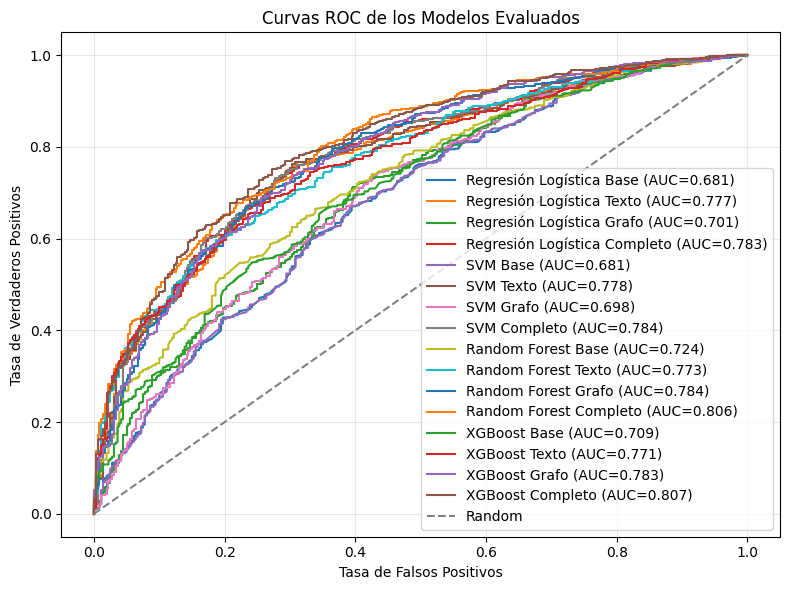

In [0]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for name, y_true, y_score in curves:
    
    # ROC 
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

# Línea base (modelo random)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")

plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Curvas ROC de los Modelos Evaluados")

plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

feature,importance_mean,importance_std
brief_title,0.05966969845589613,0.006746663685112012
closeness_norm,0.05184328758610336,0.009081036723361578
primary_purpose,0.02464061837958461,0.006745222760297004
n_countries,0.011999602404604525,0.005416359208344442
community_size,0.01166819611271631,0.003257792460753729
n_facilities,0.009425398504039173,0.0055591325595466465
n_sponsor_collaborator,0.008346120130708989,0.003399816120306725
degree_total,0.006058133379268893,0.004896146878430182
n_interventions,0.005881879094140385,0.004233759397884895
intervention_model,0.004680744109023849,0.0024658238512740185


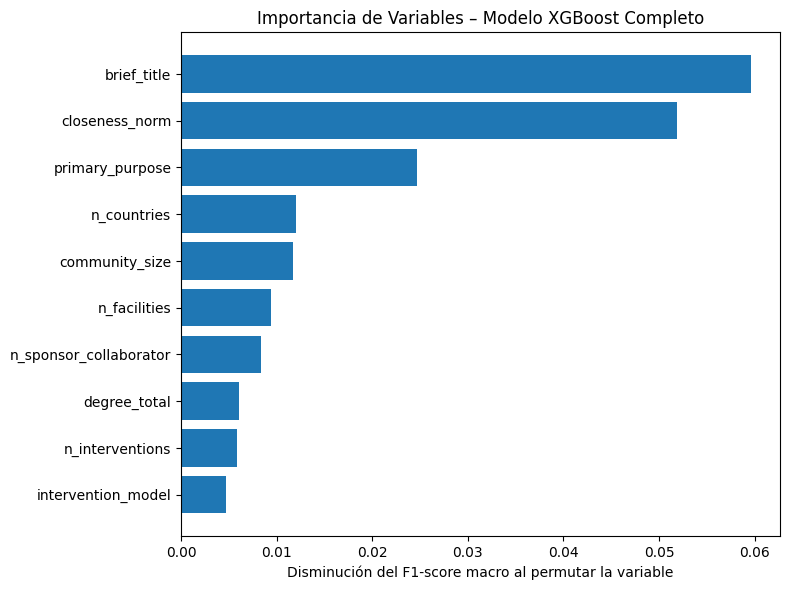

In [0]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, f1_score

# Best Model FULL
# XGBoost TABULAR + TEXT + GRAPH
pipe = best_xgb_full

# Dataset FULL
X_test = X_graph_text_test

# Main Metric
scorer = make_scorer(f1_score, average="macro")

# Permutation Importance
perm_xgb_full = permutation_importance(
    estimator=pipe,
    X=X_test,
    y=y_test,
    scoring=scorer,
    n_repeats=10,
    random_state=42,
    n_jobs=1
)

# Results DataFrame 
pi_xgb_full_df = (
    pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": perm_xgb_full.importances_mean,
        "importance_std": perm_xgb_full.importances_std
    })
    .sort_values("importance_mean", ascending=False)
)

display(pi_xgb_full_df.head(20))

# Plot Top Variables
top_n = 10

plt.figure(figsize=(8, 6))

plt.barh(
    pi_xgb_full_df.head(top_n).iloc[::-1]["feature"],
    pi_xgb_full_df.head(top_n).iloc[::-1]["importance_mean"]
)

plt.xlabel("Disminución del F1-score macro al permutar la variable")
plt.title("Importancia de Variables – Modelo XGBoost Completo")

plt.tight_layout()
plt.show()